In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import ast
from scipy.optimize import curve_fit
from shapely.geometry import LineString
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from scipy.optimize import minimize
from matplotlib.transforms import Affine2D
import scipy.special as sc

In [2]:
def DoubleEscapeSort(dataframe):
    # dataframe = dataframe.drop('10', axis=1)

    dataframe3 = dataframe[(dataframe['Multiplicity'] == 3)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)

    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if 500<= dataframe3.iloc[i,9][1]< 520 and 500<= dataframe3.iloc[i,9][0]< 520:
            rid3.append(i)

    dataframe3_double = dataframe3[dataframe3.index.isin(rid3)]
    # dataframe3_2100['Neighbors']=dataframe3_2100['Neighbors'].apply(ast.literal_eval)
    # dataframe3_2100['ChannelV']=dataframe3_2100['ChannelV'].apply(ast.literal_eval)
    dataframe3_double=dataframe3_double.reset_index(drop=True)
    return dataframe3_double

def NTD_Sort(dataframe3_double):
    NTD_data = []

    for i in range(len(dataframe3_double)):
        for j in range(len(dataframe3_double.iloc[i,10])):
            if dataframe3_double.iloc[i,10][j] in dataframe3_double.iloc[i,15]:
                NTD_data.append(i) 

    NTD_data = dataframe3_double[dataframe3_double.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    no_NTD_data = []

    for i in range(len(dataframe3_double)):
        for j in range(len(dataframe3_double.iloc[i,10])):
            if dataframe3_double.iloc[i,10][0] and dataframe3_double.iloc[i,10][1] and dataframe3_double.iloc[i,10][2] not in dataframe3_double.iloc[i,15]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe3_double[dataframe3_double.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    FC = []
    CE = []
    NC = []
    FN = []
    NE = []
    FF = []
    CC = []
    EE = []
    NN = []
    FE = []
    O = []

    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CF' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FC':
            FC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EC':
            CE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NC' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CN':
            NC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FN' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NF':
            FN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EN':
            NE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FF':
            FF.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CC':
            CC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EE':
            EE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NN':
            NN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EF':
            FE.append(i)
        else:
            O.append(i)

    FC = no_NTD_data[no_NTD_data.index.isin(FC)]
    CE = no_NTD_data[no_NTD_data.index.isin(CE)]
    NC = no_NTD_data[no_NTD_data.index.isin(NC)]
    FN = no_NTD_data[no_NTD_data.index.isin(FN)]
    NE = no_NTD_data[no_NTD_data.index.isin(NE)]
    FF = no_NTD_data[no_NTD_data.index.isin(FF)]
    CC = no_NTD_data[no_NTD_data.index.isin(CC)]
    EE = no_NTD_data[no_NTD_data.index.isin(EE)]
    NN = no_NTD_data[no_NTD_data.index.isin(NN)]
    FE = no_NTD_data[no_NTD_data.index.isin(FE)]

    FC =FC.reset_index(drop=True)
    CE =CE.reset_index(drop=True)
    NC =NC.reset_index(drop=True)
    FN =FN.reset_index(drop=True)
    NE =NE.reset_index(drop=True)
    FF =FF.reset_index(drop=True)
    CC =CC.reset_index(drop=True)
    EE =EE.reset_index(drop=True)
    NN =NN.reset_index(drop=True)
    FE =FE.reset_index(drop=True)
    return FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O

# def PrimarySecondarySplit(dataframe_1tonne_double):
#     total_2100 = []
#     total_511_cry1 = []
#     total_511_cry2 = []
    

#     for i in range(len(dataframe_1tonne_double)):
#         total_511_cry1.append(dataframe_1tonne_double.iloc[i,9][0])
#         total_511_cry2.append(dataframe_1tonne_double.iloc[i,9][1])
#         total_2100.append(dataframe_1tonne_double.iloc[i,9][2])
        
#     return total_2100, total_511_cry1, total_511_cry2

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []
    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_511.append(dataframe_1tonne_double.iloc[i,9][1])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][2])
        
    return total_2100, total_511

In [3]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
# dataframe_1tonne = dataframe_1tonne[dataframe_1tonne['Dataset'] <= 3815]
dataframe = dataframe.drop('Unnamed: 0', axis=1)
col = dataframe.pop("EnergyV")
dataframe.insert(9, col.name, col)
col2 = dataframe.pop("Neighbors")
dataframe.insert(14, col2.name, col2)
col3 = dataframe.pop("NTD")
dataframe.insert(15, col3.name, col3)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_42903/376053419.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)


In [5]:
dataframe_double = DoubleEscapeSort(dataframe)

NTD_double, no_NTD_double = NTD_Sort(dataframe_double)
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = Topology_Sort(no_NTD_double)
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = Topology_Sort(NTD_double)
NTD_1600, NTD_511 = PrimarySecondarySplit(NTD_double)
nonNTD_1600, nonNTD_511  = PrimarySecondarySplit(no_NTD_double)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_42903/4014660749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_42903/4014660749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_42903/4014660749.py:7: SettingWithCopyWarning: 
A value is 

In [6]:
print(len(NTD_511))

832


In [89]:
def NormGuassianLinear(x,mu,sigma, A,f):
    E0 = min(x)
    E1 = max(x)
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    return (1-f)*((np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2))+f*p

def NegLogLikelihoodGuassLinear(params,data):
    mu,sigma, A,f = params
    E0 = min(data)
    E1 = max(data)
    x = NormGuassianLinear(np.asarray(data),mu,sigma,A,f, E0, E1)
    x = x[x>0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLikelihoodGuassLinear(data, initial_params):
    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)
    result = minimize(NegLogLikelihoodGuassLinear, initial_params, args=(data),
                      method='Nelder-Mead', bounds=[(0, None), (0, None),(-bound_A, bound_A) ,(0,1)])
    return result.x

def Chi2(data, arr):
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = NormGuassianLinear(filtered_bin_centers, *arr)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Graph(data, arr):
    mu_fit, sigma_fit, A_fit, f_fit = arr
    
    x_values = np.linspace(min(data), max(data), 1000)
    bin_num = int(max(data) - min(data))
    bin_width = (max(data) - min(data))/bin_num
    
    fitted_pdf = NormGuassianLinear(x_values, mu_fit, sigma_fit, A_fit, f_fit, min(x_values), max(x_values))*len(data)*bin_width
    linear = (f_fit*(1+A_fit*(x_values-((min(data)+max(data))/2)))/(max(data)-min(data)))*len(data)*bin_width
    guass = (1-f_fit)*((np.exp(-(x_values-mu_fit)**2/(2*sigma_fit**2)))/np.sqrt(2*np.pi*sigma_fit**2))*len(data)*bin_width
    
    return x_values, fitted_pdf, linear, guass

def Residual_Plot(data, arr):
    mu,sigma, A,f = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormGuassianLinear(filtered_bin_centers, mu, sigma, A, f, E0, E1)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

In [81]:
from iminuit import cost, Minuit

data = np.asarray(nonNTD_511)

c = cost.UnbinnedNLL(data, NormGuassianLinear)

E0 = min(data)
E1 = max(data)
Ec = (E0+E1)/2
bound_A = 1/(Ec-E0)

m = Minuit(c,mu=511.1537254374714, sigma=2.626008553941729, A=0.003, f=0.5)
m.limits["f"] = (0, 1)
m.limits["mu", "sigma"] = (0, None)
m.limits["A"] = (-bound_A, bound_A)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.344e+04                  │              Nfcn = 129              │
│ EDM = 8.93e-06 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │  511.183  │   0.027   │            │            │    0    │         │       │
│ 1 │ sigma │   2.246   │   0.025   │            │            │    0    │         │       │
│ 2 │ A     │  -0.030   │   0.007   │            │            │-0.100537│0.100537 │       │
│ 3 │ f     │   0.118   │   0.006   │            │            │    0    │    1    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────┐
│       │       mu    sigma        A        f │
├───────┼─────────────────────────────────────┤
│    mu │ 0.000714        0 -0.05e-3 -0.01e-3 │
│ sigma │        0 0.000644 -0.05e-3 -0.09e-3 │
│     A │ -0.05e-3 -0.05e-3 4.37e-05  0.02e-3 │
│     f │ -0.01e-3 -0.09e-3  0.02e-3 4.02e-05 │
└───────┴─────────────────────────────────────┘

4.994325108737309


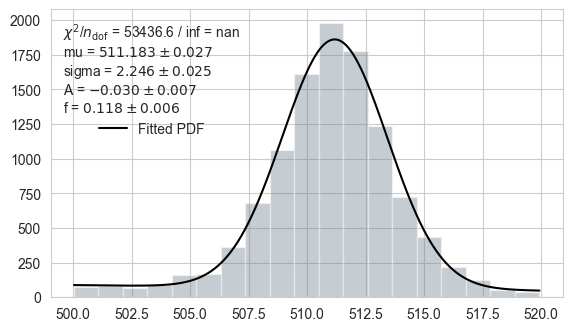

In [90]:
bin_num = int(max(nonNTD_511) - min(nonNTD_511))
bin_width = (max(nonNTD_511) - min(nonNTD_511))/bin_num

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
x_values = np.linspace(min(data), max(data), 1000)
ax.plot(x_values, NormGuassianLinear(x_values, *m.values)*len(data)*bin_width,label='Fitted PDF', color='black')
ax.hist(nonNTD_511, bins = bin_num , color='slategray', alpha=0.4);

fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m.fval:.1f} / {m.ndof:.0f} = {m.fmin.reduced_chi2:.1f}",
]

for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")

ax.legend(title="\n".join(fit_info), frameon=False)

print(Chi2(nonNTD_511, m.values)/(bin_num-4))


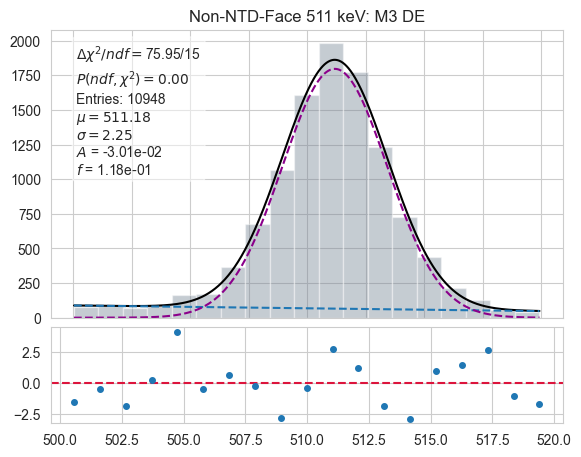

In [69]:
mu = 511.1537254374714
sigma = 2.626008553941729
A = 0.003
f = 0.5
initial_parms = [mu, sigma, A, f]
fit_arr = MinimizeNegLogLikelihoodGuassLinear(nonNTD_511, initial_parms)
# print(f"Fitted parameters: {fitted_params}")

bin_num = int(max(nonNTD_511) - min(nonNTD_511))
bin_width = (max(nonNTD_511) - min(nonNTD_511))/bin_num

x_values, fitted_pdf, linear, guass = Graph(nonNTD_511, fit_arr)

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(Chi2(nonNTD_511, fit_arr), decimals=2)) +'/' +str(bin_num - 4, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num-4, Chi2(nonNTD_511, fit_arr)), ),
    'Entries: ' + (str(len(nonNTD_511))),
    r'$\mu=%.2f$' % (fit_arr[0], ),
    r'$\sigma=%.2f$' % (fit_arr[1], ),
    r'$A$ = ' + str(np.format_float_scientific(fit_arr[2], precision = 2), ),
    r'$f$ = ' + str(np.format_float_scientific(fit_arr[3], precision = 2),)
    ))

ax.plot(x_values, fitted_pdf,label='Fitted PDF', color='black')
ax.plot(x_values,linear, label='Linear Background', linestyle='--')
ax.plot(x_values, guass, label = 'Gaussian', linestyle='--', color='darkmagenta')

ax.hist(nonNTD_511, bins = bin_num , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('Non-NTD-Face 511 keV: M3 DE')

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(nonNTD_511, fit_arr)[0],Residual_Plot(nonNTD_511, fit_arr)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

In [70]:
FC_1600, FC_511 = PrimarySecondarySplit(FC)
CE_1600, CE_511 = PrimarySecondarySplit(CE)
NC_1600, NC_511 = PrimarySecondarySplit(NC)
FN_1600, FN_511 = PrimarySecondarySplit(FN)
NE_1600, NE_511= PrimarySecondarySplit(NE)
FF_1600, FF_511 = PrimarySecondarySplit(FF)
CC_1600, CC_511= PrimarySecondarySplit(CC)
EE_1600, EE_511 = PrimarySecondarySplit(EE)
NN_1600, NN_511 = PrimarySecondarySplit(NN)
FE_1600, FE_511 = PrimarySecondarySplit(FE)

FCarr = MinimizeNegLogLikelihoodGuassLinear(FC_511, [np.mean(FC_511), np.std(FC_511), A, f])
CEarr = MinimizeNegLogLikelihoodGuassLinear(CE_511, [np.mean(CE_511), np.std(CE_511), A, f])
NCarr = MinimizeNegLogLikelihoodGuassLinear(NC_511, [np.mean(NC_511), np.std(NC_511), A, f])
FNarr = MinimizeNegLogLikelihoodGuassLinear(FN_511, [np.mean(FN_511), np.std(FN_511), A, f])
NEarr = MinimizeNegLogLikelihoodGuassLinear(NE_511, [np.mean(NE_511), np.std(NE_511), A, f])
FFarr= MinimizeNegLogLikelihoodGuassLinear(FF_511, [np.mean(FF_511), np.std(FF_511), A, f])
EEarr= MinimizeNegLogLikelihoodGuassLinear(EE_511, [np.mean(EE_511), np.std(EE_511), A, f])
NNarr = MinimizeNegLogLikelihoodGuassLinear(NN_511, [np.mean(NN_511), np.std(NN_511), A, f])
FEarr = MinimizeNegLogLikelihoodGuassLinear(FE_511, [np.mean(FE_511), np.std(FE_511), A, f])
CCarr = MinimizeNegLogLikelihoodGuassLinear(CC_511, [np.mean(CC_511), np.std(CC_511), A, f])


In [77]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def TopologyPlots(hist_data, initial_parms, topologies, cols, rows):
    bin_num = []
    xvals = []
    chi2s = []
    fitvals = []
    guassvals = []
    linearvals = []
    
    for i in range(len(hist_data)):
        x, PDF_fit, linear, guass = Graph(hist_data[i], initial_parms[i])
        bin_num.append(int(max(hist_data[i])-min(hist_data[i])))
        xvals.append(x)
        fitvals.append(PDF_fit)
        linearvals.append(linear)
        guassvals.append(guass)
        
        chi2s.append(Chi2(hist_data[i], initial_parms[i]))
    
    pvals = []
    
    for j in range(len(chi2s)):
        pvals.append(PValue(bin_num[j],chi2s[j]))
    
    means = []
    sigmas = []
    As =[]
    fs = []
    
    for i in range(len(initial_parms)):
        means.append(initial_parms[i][0])
        sigmas.append(initial_parms[i][1])
        As.append(initial_parms[i][2])
        fs.append(initial_parms[i][3])
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': hist_data,
        'X-axis': xvals,
        'Fit': fitvals,
        'Linear': linearvals,
        'Guass': guassvals,
        'Means': means,
        'Sigmas': sigmas,
        'A': As,
        'f': fs, 
        'Chi2': chi2s,
        'p-value': pvals}
    
    df = pd.DataFrame(data)
    
    fig, axs = plt.subplots(cols, rows, figsize=(10, 15))
    props = dict(boxstyle='round', facecolor='whitesmoke')

    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) + '/' + str(df['Bin Num'][i] - 6, ),
            r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
            'Entries: ' + (str(len(df['Histogram Data'][i]))),
            r'$\mu=%.2f$' % (df['Means'][i], ),
            r'$\sigma=%.2f$' % (df['Sigmas'][i], ),
            r'$A$ = ' + str(np.format_float_scientific(df['A'][i], precision = 2), ),
            r'$f$ = ' + str(np.format_float_scientific(df['f'][i], precision = 2), )))
            
            ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=9, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], color='slategray', alpha=0.4)
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='black')
            ax.plot(df['X-axis'][i], df['Linear'][i], label='Linear Bckg', linestyle='--', color='purple')
            ax.plot(df['X-axis'][i], df['Guass'][i], label='Gaussian', linestyle='--', color='blue')
            ax.set_title(df["Topologies"][i])
            ax.legend(fontsize = 8, loc='upper right')
            ax.set_xticks([])
            
            ax2 = divider.append_axes("bottom", size="40%", pad=0.15)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(hist_data[i], initial_parms[i])[0],Residual_Plot(hist_data[i], initial_parms[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
    plt.tight_layout()
    plt.show()

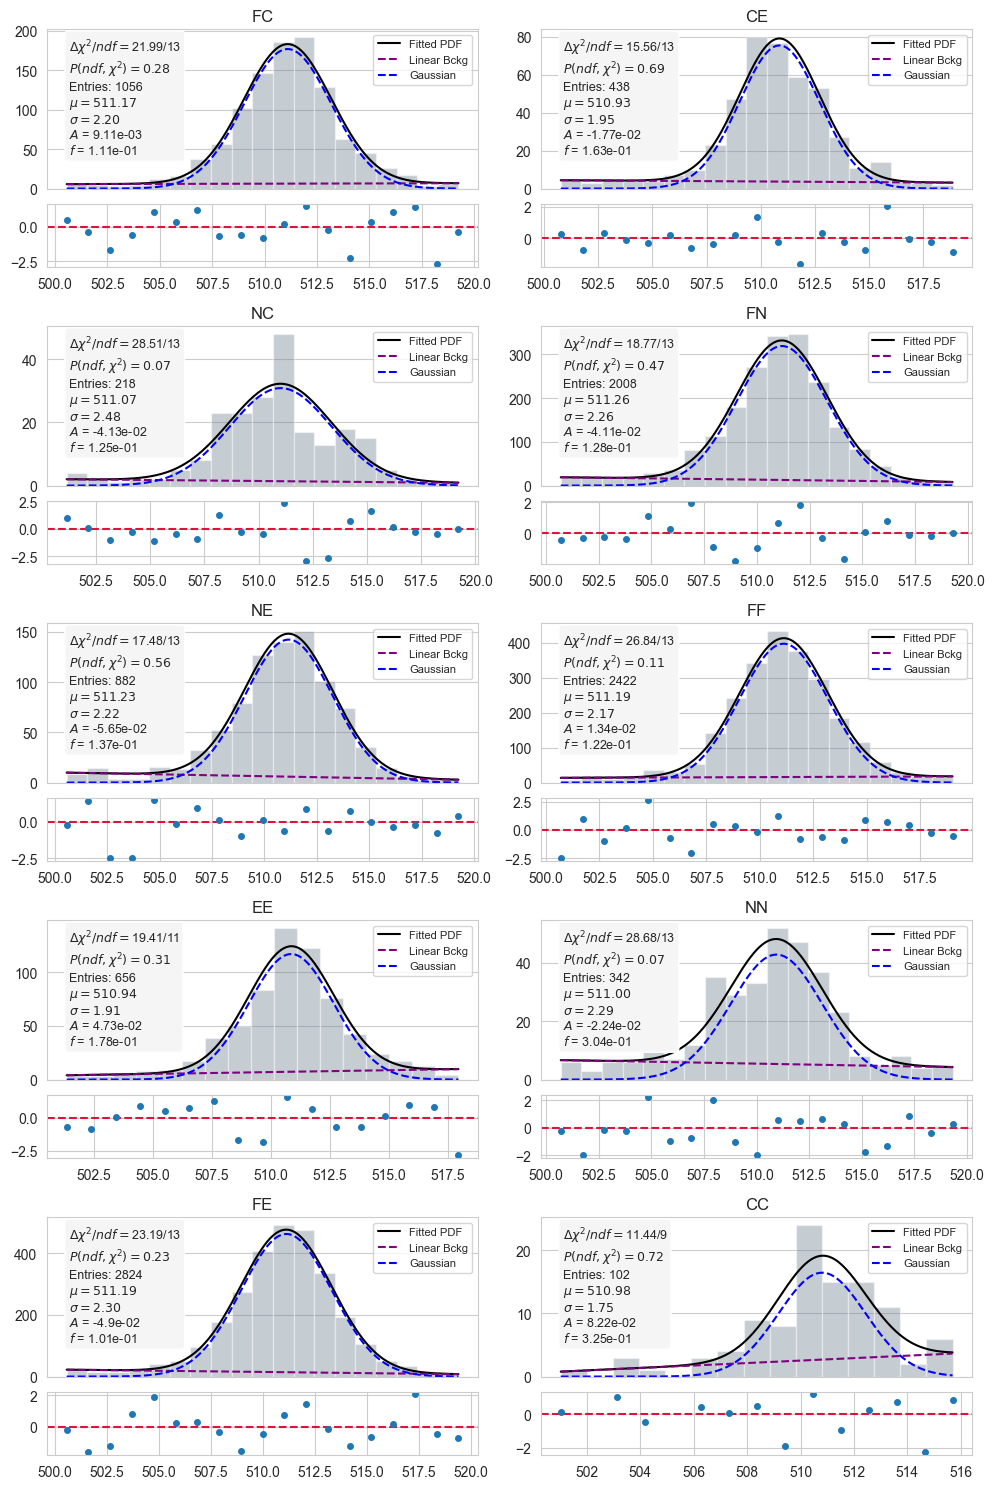

In [78]:
hist_data = [FC_511, CE_511, NC_511, FN_511, NE_511, FF_511, EE_511, NN_511, FE_511, CC_511]
initial_parms = [FCarr, CEarr, NCarr, FNarr, NEarr, FFarr, EEarr, NNarr, FEarr, CCarr]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

TopologyPlots(hist_data, initial_parms, topologies,5,2)

Text(0.5, 1.0, 'CC')

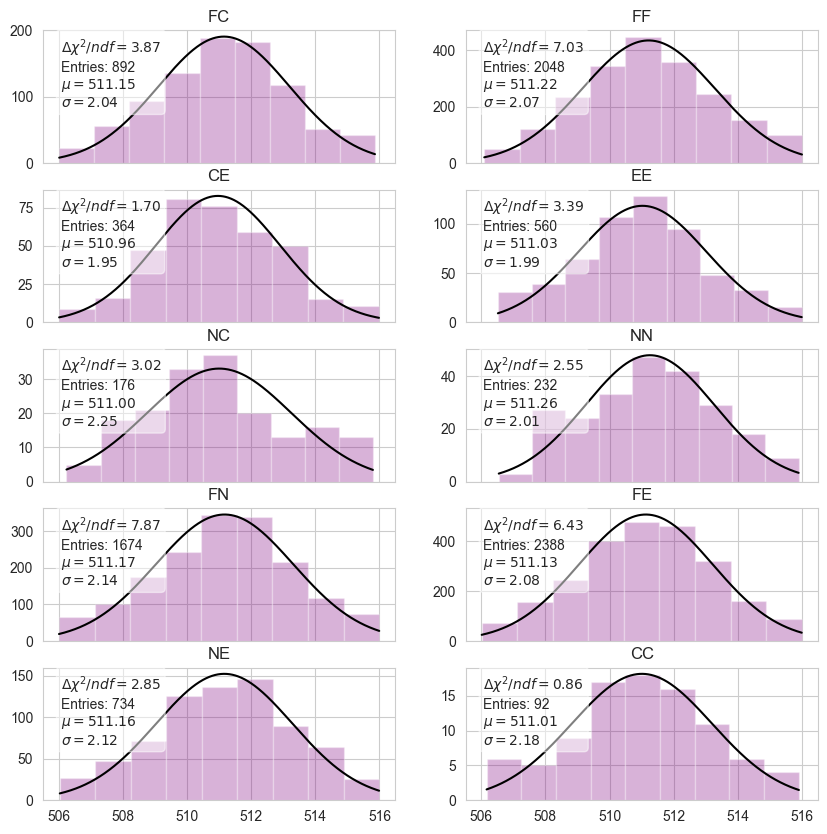

In [18]:
fig, ax = plt.subplots(5,2, sharex='col', figsize=(10, 10))
# fig.text(0.04, 0.5, 'Counts', va='center', rotation = 'vertical')
# fig.text(0.5, 0.04, 'Energy (keV)', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# fig.suptitle('Non-NTD Face 511 keV All Crystal Topology Fits')

textFC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(FC_511, FCmu_fit, FCsigma_fit)/(int(max(FC_511)-min(FC_511)) - 2), ),
    'Entries: ' + (str(len(FC_511))),
    r'$\mu=%.2f$' % (FCmu_fit, ),
    r'$\sigma=%.2f$' % (FCsigma_fit, )))

ax[0,0].plot(FCx, FC_fit,label='FC Fit', color='black')
ax[0,0].hist(FC_511, bins = int(max(FC_511)-min(FC_511)) , alpha=0.3, color='purple')
ax[0,0].text(0.05, 0.95, textFC, transform=ax[0,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('FC')
##############
textCE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(CE_511, CEmu_fit, CEsigma_fit)/(int(max(CE_511)-min(CE_511)) - 2), ),
    'Entries: ' + (str(len(CE_511))),
    r'$\mu=%.2f$' % (CEmu_fit, ),
    r'$\sigma=%.2f$' % (CEsigma_fit, )))

ax[1,0].plot(CEx, CE_fit, color='black')
ax[1,0].hist(CE_511, bins = int(max(CE_511)-min(CE_511)) , alpha=0.3, color='purple')
ax[1,0].text(0.05, 0.95, textCE, transform=ax[1,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('CE')
#######
textNC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(NC_511, NCmu_fit, NCsigma_fit)/(int(max(NC_511)-min(NC_511)) - 2), ),
    'Entries: ' + (str(len(NC_511))),
    r'$\mu=%.2f$' % (NCmu_fit, ),
    r'$\sigma=%.2f$' % (NCsigma_fit, )))

ax[2,0].plot(NCx, NC_fit, color='black')
ax[2,0].hist(NC_511, bins = int(max(NC_511)-min(NC_511)) , alpha=0.3, color='purple')
ax[2,0].text(0.05, 0.95, textNC, transform=ax[2,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,0].set_title('NC')
########
textFN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(FN_511, FNmu_fit, FNsigma_fit)/(int(max(FN_511)-min(FN_511)) - 2), ),
    'Entries: ' + (str(len(FN_511))),
    r'$\mu=%.2f$' % (FNmu_fit, ),
    r'$\sigma=%.2f$' % (FNsigma_fit, )))

ax[3,0].plot(FNx, FN_fit, color='black')
ax[3,0].hist(FN_511, bins = int(max(FN_511)-min(FN_511)), alpha=0.3, color='purple')
ax[3,0].text(0.05, 0.95, textFN, transform=ax[3,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[3,0].set_title('FN')
########
textNE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(NE_511, NEmu_fit, NEsigma_fit)/(int(max(NE_511)-min(NE_511)) - 2), ),
    'Entries: ' + (str(len(NE_511))),
    r'$\mu=%.2f$' % (NEmu_fit, ),
    r'$\sigma=%.2f$' % (NEsigma_fit, )))

ax[4,0].plot(NEx, NE_fit, color='black')
ax[4,0].hist(NE_511, bins = int(max(NE_511)-min(NE_511)) , alpha=0.3, color='purple')
ax[4,0].text(0.05, 0.95, textNE, transform=ax[4,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[4,0].set_title('NE')
########
textFF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(FF_511, FFmu_fit, FFsigma_fit)/(int(max(FF_511)-min(FF_511)) - 2), ),
    'Entries: ' + (str(len(FF_511))),
    r'$\mu=%.2f$' % (FFmu_fit, ),
    r'$\sigma=%.2f$' % (FFsigma_fit, )))

ax[0,1].plot(FFx, FF_fit, color='black')
ax[0,1].hist(FF_511, bins = int(max(FF_511)-min(FF_511)) , alpha=0.3, color='purple')
ax[0,1].text(0.05, 0.95, textFF, transform=ax[0,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('FF')
########
textEE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(EE_511, EEmu_fit, EEsigma_fit)/(int(max(EE_511)-min(EE_511)) - 2), ),
    'Entries: ' + (str(len(EE_511))),
    r'$\mu=%.2f$' % (EEmu_fit, ),
    r'$\sigma=%.2f$' % (EEsigma_fit, )))

ax[1,1].plot(EEx, EE_fit, color='black')
ax[1,1].hist(EE_511, bins = int(max(EE_511)-min(EE_511)), alpha=0.3, color='purple')
ax[1,1].text(0.05, 0.95, textEE, transform=ax[1,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('EE')
########
textNN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(NN_511, NNmu_fit, NNsigma_fit)/(int(max(NN_511)-min(NN_511)) - 2), ),
    'Entries: ' + (str(len(NN_511))),
    r'$\mu=%.2f$' % (NNmu_fit, ),
    r'$\sigma=%.2f$' % (NNsigma_fit, )))

ax[2,1].plot(NNx, NN_fit, color='black')
ax[2,1].hist(NN_511, bins = int(max(NN_511)-min(NN_511)), alpha=0.3, color='purple')
ax[2,1].text(0.05, 0.95, textNN, transform=ax[2,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,1].set_title('NN')
########
textFE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(FE_511, FEmu_fit, FEsigma_fit)/(int(max(FE_511)-min(FE_511)) - 2), ),
    'Entries: ' + (str(len(FE_511))),
    r'$\mu=%.2f$' % (FEmu_fit, ),
    r'$\sigma=%.2f$' % (FEsigma_fit, )))

ax[3,1].plot(FEx, FE_fit, color='black')
ax[3,1].hist(FE_511, bins = int(max(FE_511)-min(FE_511)), alpha=0.3, color='purple')
ax[3,1].text(0.05, 0.95, textFE, transform=ax[3,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[3,1].set_title('FE')
#########
textCC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(CC_511, CCmu_fit, CCsigma_fit)/(int(max(CC_511)-min(CC_511)) - 2), ),
    'Entries: ' + (str(len(CC_511))),
    r'$\mu=%.2f$' % (CCmu_fit, ),
    r'$\sigma=%.2f$' % (CCsigma_fit, )))

ax[4,1].plot(CCx, CC_fit, color='black')
ax[4,1].hist(CC_511, bins = int(max(CC_511)-min(CC_511)) , alpha=0.3, color='purple')
ax[4,1].text(0.05, 0.95, textCC, transform=ax[4,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[4,1].set_title('CC')

In [75]:
def NegLogLikelihoodGuassExp(params,data):
    mu,sigma = params
    LogL = 0
    for k in data:
        x = Guassian(k,mu,sigma)
        # if x > 0:
        LogL += np.log(x)
    return -2*LogL

def Uncertainity(data, mu, sigma):
    params = [mu, sigma]
    arr1 = NegLogLikelihoodGuassExp(params, data)
    arr2 = arr1 - min(arr1)
    xaxis = LineString(np.column_stack((arr2,np.linspace(1,1, len(arr2)))))
    if isinstance(mu, float) == False: 
        curve = LineString(np.column_stack((mu, arr2)))
        intersection = xaxis.intersection(curve)
    elif isinstance(mu, float) == True:
        curve = LineString(np.column_stack((sigma, arr2)))
        intersection = curve.intersection(xaxis)
    if str(intersection) == 'LINESTRING Z EMPTY':
        intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.01))[0]
        intersection = mu[intersection_indices]
        # intersection_y = arr2[intersection_indices]
        # intersection = list(zip(intersection_x, intersection_y))
    return intersection, arr2

def Errors(mu_intersections, means):
    upper_errs = []
    lower_errs = []

    for i in range(len(mu_intersections)):
        if mu_intersections[i][0] < mu_intersections[i][1]:
            upper_errs.append(mu_intersections[i][1])
            lower_errs.append(mu_intersections[i][0])
        else:
            upper_errs.append(mu_intersections[i][0])
            lower_errs.append(mu_intersections[i][1])

    top_errs = []
    bot_errs = []
    for i in range(len(upper_errs)):
        top_errs.append(abs(means[i]-upper_errs[i]))
        bot_errs.append(abs(means[i]-lower_errs[i]))

    asymmetric_errormu = np.array(list(zip(bot_errs, top_errs))).T
    return asymmetric_errormu

In [46]:
FCmu_arrc1 = np.linspace(FCmu_fitc1-5, FCmu_fitc1+5, 1000) 
CEmu_arrc1 = np.linspace(CEmu_fitc1-5, CEmu_fitc1+5, 1000) 
NCmu_arrc1 = np.linspace(NCmu_fitc1-5, NCmu_fitc1+5, 1000)
FNmu_arrc1 = np.linspace(FNmu_fitc1-5, FNmu_fitc1+5, 1000)
NEmu_arrc1 = np.linspace(NEmu_fitc1-5, NEmu_fitc1+5, 1000)
FFmu_arrc1 = np.linspace(FFmu_fitc1-5, FFmu_fitc1+5, 1000)
EEmu_arrc1 = np.linspace(EEmu_fitc1-5, EEmu_fitc1+5, 1000)
NNmu_arrc1 = np.linspace(NNmu_fitc1-5, NNmu_fitc1+5, 1000) 
FEmu_arrc1 = np.linspace(FEmu_fitc1-5, FEmu_fitc1+5, 1000)
CCmu_arrc1 = np.linspace(CCmu_fitc1-8, CCmu_fitc1+8, 2000) 

FCintersection_muc1, FCerror_muc1 = Uncertainity(FC_511c1, FCmu_arrc1, FCsigma_fitc1)
CEintersection_muc1, CEerror_muc1 = Uncertainity(CE_511c1, CEmu_arrc1, CEsigma_fitc1)
NCintersection_muc1, NCerror_muc1 = Uncertainity(NC_511c1, NCmu_arrc1, NCsigma_fitc1)
FNintersection_muc1, FNerror_muc1 = Uncertainity(FN_511c1, FNmu_arrc1, FNsigma_fitc1)
NEintersection_muc1, NEerror_muc1 = Uncertainity(NE_511c1, NEmu_arrc1, NEsigma_fitc1)
FFintersection_muc1, FFerror_muc1 = Uncertainity(FF_511c1, FFmu_arrc1, FFsigma_fitc1) 
EEintersection_muc1, EEerror_muc1 = Uncertainity(EE_511c1, EEmu_arrc1, EEsigma_fitc1)
NNintersection_muc1, NNerror_muc1 = Uncertainity(NN_511c1, NNmu_arrc1, NNsigma_fitc1) 
FEintersection_muc1, FEerror_muc1 = Uncertainity(FE_511c1, FEmu_arrc1, FEsigma_fitc1)
CCintersection_muc1, CCerror_muc1 = Uncertainity(CC_511c1, CCmu_arrc1, CCsigma_fitc1)

FCmu_arrc2 = np.linspace(FCmu_fitc2-5, FCmu_fitc2+5, 1000) 
CEmu_arrc2 = np.linspace(CEmu_fitc2-5, CEmu_fitc2+5, 1000) 
NCmu_arrc2 = np.linspace(NCmu_fitc2-5, NCmu_fitc2+5, 1000)
FNmu_arrc2 = np.linspace(FNmu_fitc2-5, FNmu_fitc2+5, 1000)
NEmu_arrc2 = np.linspace(NEmu_fitc2-5, NEmu_fitc2+5, 1000)
FFmu_arrc2 = np.linspace(FFmu_fitc2-5, FFmu_fitc2+5, 1000)
EEmu_arrc2 = np.linspace(EEmu_fitc2-5, EEmu_fitc2+5, 1000)
NNmu_arrc2 = np.linspace(NNmu_fitc2-5, NNmu_fitc2+5, 1000) 
FEmu_arrc2 = np.linspace(FEmu_fitc2-5, FEmu_fitc2+5, 1000)
CCmu_arrc2 = np.linspace(CCmu_fitc2-8, CCmu_fitc2+8, 2000) 

FCintersection_muc2, FCerror_muc2 = Uncertainity(FC_511c2, FCmu_arrc2, FCsigma_fitc2)
CEintersection_muc2, CEerror_muc2 = Uncertainity(CE_511c2, CEmu_arrc2, CEsigma_fitc2)
NCintersection_muc2, NCerror_muc2 = Uncertainity(NC_511c2, NCmu_arrc2, NCsigma_fitc2)
FNintersection_muc2, FNerror_muc2 = Uncertainity(FN_511c2, FNmu_arrc2, FNsigma_fitc2)
NEintersection_muc2, NEerror_muc2 = Uncertainity(NE_511c2, NEmu_arrc2, NEsigma_fitc2)
FFintersection_muc2, FFerror_muc2 = Uncertainity(FF_511c2, FFmu_arrc2, FFsigma_fitc2) 
EEintersection_muc2, EEerror_muc2 = Uncertainity(EE_511c2, EEmu_arrc2, EEsigma_fitc2)
NNintersection_muc2, NNerror_muc2 = Uncertainity(NN_511c2, NNmu_arrc2, NNsigma_fitc2) 
FEintersection_muc2, FEerror_muc2 = Uncertainity(FE_511c2, FEmu_arrc2, FEsigma_fitc2)
CCintersection_muc2, CCerror_muc2 = Uncertainity(CC_511c2, CCmu_arrc2, CCsigma_fitc2)

In [76]:
FCmu_arr = np.linspace(FCmu_fit-5, FCmu_fit+5, 1000) 
CEmu_arr = np.linspace(CEmu_fit-5, CEmu_fit+5, 1000) 
NCmu_arr = np.linspace(NCmu_fit-5, NCmu_fit+5, 1000)
FNmu_arr = np.linspace(FNmu_fit-5, FNmu_fit+5, 1000)
NEmu_arr = np.linspace(NEmu_fit-5, NEmu_fit+5, 1000)
FFmu_arr = np.linspace(FFmu_fit-5, FFmu_fit+5, 1000)
EEmu_arr = np.linspace(EEmu_fit-5, EEmu_fit+5, 1000)
NNmu_arr = np.linspace(NNmu_fit-5, NNmu_fit+5, 1000) 
FEmu_arr = np.linspace(FEmu_fit-5, FEmu_fit+5, 1000)
CCmu_arr = np.linspace(CCmu_fit-8, CCmu_fit+8, 2000) 

FCintersection_mu, FCerror_mu = Uncertainity(FC_511, FCmu_arr, FCsigma_fit)
CEintersection_mu, CEerror_mu = Uncertainity(CE_511, CEmu_arr, CEsigma_fit)
NCintersection_mu, NCerror_mu = Uncertainity(NC_511, NCmu_arr, NCsigma_fit)
FNintersection_mu, FNerror_mu = Uncertainity(FN_511, FNmu_arr, FNsigma_fit)
NEintersection_mu, NEerror_mu = Uncertainity(NE_511, NEmu_arr, NEsigma_fit)
FFintersection_mu, FFerror_mu = Uncertainity(FF_511, FFmu_arr, FFsigma_fit) 
EEintersection_mu, EEerror_mu = Uncertainity(EE_511, EEmu_arr, EEsigma_fit)
NNintersection_mu, NNerror_mu = Uncertainity(NN_511, NNmu_arr, NNsigma_fit) 
FEintersection_mu, FEerror_mu = Uncertainity(FE_511, FEmu_arr, FEsigma_fit)
CCintersection_mu, CCerror_mu = Uncertainity(CC_511, CCmu_arr, CCsigma_fit)

In [30]:
FCsigma_arrc1 = np.linspace(FCsigma_fitc1/2, FCsigma_fitc1*2, 100)
CEsigma_arrc1 = np.linspace(CEsigma_fitc1/2, CEsigma_fitc1*2, 100)
NCsigma_arrc1 = np.linspace(NCsigma_fitc1/2, NCsigma_fitc1*2, 100)
FNsigma_arrc1 = np.linspace(FNsigma_fitc1/2, FNsigma_fitc1*2, 100)
NEsigma_arrc1 = np.linspace(NEsigma_fitc1/2, NEsigma_fitc1*2, 100)
FFsigma_arrc1 = np.linspace(FFsigma_fitc1/2, FFsigma_fitc1*2, 100)
EEsigma_arrc1 = np.linspace(EEsigma_fitc1/2, EEsigma_fitc1*2, 100)
NNsigma_arrc1 = np.linspace(NNsigma_fitc1/2, NNsigma_fitc1*2, 100)
FEsigma_arrc1 = np.linspace(FEsigma_fitc1/2, FEsigma_fitc1*2, 100)
CCsigma_arrc1 = np.linspace(CCsigma_fitc1/2, CCsigma_fitc1*2, 100)

FCintersection_sigmac1, FCerror_sigmac1 = Uncertainity(FC_511c1, FCmu_fitc1, FCsigma_arrc1)
CEintersection_sigmac1, CEerror_sigmac1 = Uncertainity(CE_511c1, CEmu_fitc1, CEsigma_arrc1)
NCintersection_sigmac1, NCerror_sigmac1 = Uncertainity(NC_511c1, NCmu_fitc1, NCsigma_arrc1)
FNintersection_sigmac1, FNerror_sigmac1 = Uncertainity(FN_511c1, FNmu_fitc1, FNsigma_arrc1)
NEintersection_sigmac1, NEerror_sigmac1 = Uncertainity(NE_511c1, NEmu_fitc1, NEsigma_arrc1)
FFintersection_sigmac1, FFerror_sigmac1 = Uncertainity(FF_511c1, FFmu_fitc1, FFsigma_arrc1)
EEintersection_sigmac1, EEerror_sigmac1 = Uncertainity(EE_511c1, EEmu_fitc1, EEsigma_arrc1)
CCintersection_sigmac1, CCerror_sigmac1 = Uncertainity(CC_511c1, CCmu_fitc1, CCsigma_arrc1)
NNintersection_sigmac1, NNerror_sigmac1 = Uncertainity(NN_511c1, NNmu_fitc1, NNsigma_arrc1) 
FEintersection_sigmac1, FEerror_sigmac1 = Uncertainity(FE_511c1, FEmu_fitc1, FEsigma_arrc1) 

FCsigma_arrc2 = np.linspace(FCsigma_fitc2/2, FCsigma_fitc2*2, 100)
CEsigma_arrc2 = np.linspace(CEsigma_fitc2/2, CEsigma_fitc2*2, 100)
NCsigma_arrc2 = np.linspace(NCsigma_fitc2/2, NCsigma_fitc2*2, 100)
FNsigma_arrc2 = np.linspace(FNsigma_fitc2/2, FNsigma_fitc2*2, 100)
NEsigma_arrc2 = np.linspace(NEsigma_fitc2/2, NEsigma_fitc2*2, 100)
FFsigma_arrc2 = np.linspace(FFsigma_fitc2/2, FFsigma_fitc2*2, 100)
EEsigma_arrc2 = np.linspace(EEsigma_fitc2/2, EEsigma_fitc2*2, 100)
NNsigma_arrc2 = np.linspace(NNsigma_fitc2/2, NNsigma_fitc2*2, 100)
FEsigma_arrc2 = np.linspace(FEsigma_fitc2/2, FEsigma_fitc2*2, 100)
CCsigma_arrc2 = np.linspace(CCsigma_fitc2/2, CCsigma_fitc2*2, 100)

FCintersection_sigmac2, FCerror_sigmac2 = Uncertainity(FC_511c2, FCmu_fitc2, FCsigma_arrc2)
CEintersection_sigmac2, CEerror_sigmac2 = Uncertainity(CE_511c2, CEmu_fitc2, CEsigma_arrc2)
NCintersection_sigmac2, NCerror_sigmac2 = Uncertainity(NC_511c2, NCmu_fitc2, NCsigma_arrc2)
FNintersection_sigmac2, FNerror_sigmac2 = Uncertainity(FN_511c2, FNmu_fitc2, FNsigma_arrc2)
NEintersection_sigmac2, NEerror_sigmac2 = Uncertainity(NE_511c2, NEmu_fitc2, NEsigma_arrc2)
FFintersection_sigmac2, FFerror_sigmac2 = Uncertainity(FF_511c2, FFmu_fitc2, FFsigma_arrc2)
EEintersection_sigmac2, EEerror_sigmac2 = Uncertainity(EE_511c2, EEmu_fitc2, EEsigma_arrc2)
CCintersection_sigmac2, CCerror_sigmac2 = Uncertainity(CC_511c2, CCmu_fitc2, CCsigma_arrc2)
NNintersection_sigmac2, NNerror_sigmac2 = Uncertainity(NN_511c2, NNmu_fitc2, NNsigma_arrc2) 
FEintersection_sigmac2, FEerror_sigmac2 = Uncertainity(FE_511c2, FEmu_fitc2, FEsigma_arrc2) 

In [77]:
FCsigma_arr = np.linspace(FCsigma_fit/2, FCsigma_fit*2, 100)
CEsigma_arr = np.linspace(CEsigma_fit/2, CEsigma_fit*2, 100)
NCsigma_arr = np.linspace(NCsigma_fit/2, NCsigma_fit*2, 100)
FNsigma_arr = np.linspace(FNsigma_fit/2, FNsigma_fit*2, 100)
NEsigma_arr = np.linspace(NEsigma_fit/2, NEsigma_fit*2, 100)
FFsigma_arr = np.linspace(FFsigma_fit/2, FFsigma_fit*2, 100)
EEsigma_arr = np.linspace(EEsigma_fit/2, EEsigma_fit*2, 100)
NNsigma_arr = np.linspace(NNsigma_fit/2, NNsigma_fit*2, 100)
FEsigma_arr = np.linspace(FEsigma_fit/2, FEsigma_fit*2, 100)
CCsigma_arr = np.linspace(CCsigma_fit/2, CCsigma_fit*2, 100)

FCintersection_sigma, FCerror_sigma = Uncertainity(FC_511, FCmu_fit, FCsigma_arr)
CEintersection_sigma, CEerror_sigma = Uncertainity(CE_511, CEmu_fit, CEsigma_arr)
NCintersection_sigma, NCerror_sigma = Uncertainity(NC_511, NCmu_fit, NCsigma_arr)
FNintersection_sigma, FNerror_sigma = Uncertainity(FN_511, FNmu_fit, FNsigma_arr)
NEintersection_sigma, NEerror_sigma = Uncertainity(NE_511, NEmu_fit, NEsigma_arr)
FFintersection_sigma, FFerror_sigma = Uncertainity(FF_511, FFmu_fit, FFsigma_arr)
EEintersection_sigma, EEerror_sigma = Uncertainity(EE_511, EEmu_fit, EEsigma_arr)
CCintersection_sigma, CCerror_sigma = Uncertainity(CC_511, CCmu_fit, CCsigma_arr)
NNintersection_sigma, NNerror_sigma = Uncertainity(NN_511, NNmu_fit, NNsigma_arr) 
FEintersection_sigma, FEerror_sigma = Uncertainity(FE_511, FEmu_fit, FEsigma_arr) 

In [78]:
# sigma_arrc1 = np.linspace(sigma_fitc1/2, sigma_fitc1*2, 100)
# mu_arrc1 = np.linspace(mu_fitc1-5, mu_fitc1+5, 1000)
# intersection_sigmac1, error_sigmac1 = Uncertainity(nonNTD_511c1, mu_fitc1, sigma_arrc1)
# intersection_muc1, error_muc1 = Uncertainity(nonNTD_511c1, mu_arrc1, sigma_fitc1)

# sigma_arrc2 = np.linspace(sigma_fitc2/2, sigma_fitc2*2, 100)
# mu_arrc2 = np.linspace(mu_fitc2-5, mu_fitc2+5, 1000)
# intersection_sigmac2, error_sigmac2 = Uncertainity(nonNTD_511c2, mu_fitc2, sigma_arrc2)
# intersection_muc2, error_muc2 = Uncertainity(nonNTD_511c2, mu_arrc2, sigma_fitc2)

sigma_arr = np.linspace(sigma_fit/2, sigma_fit*2, 100)
mu_arr = np.linspace(mu_fit-5, mu_fit+5, 1000)
intersection_sigma, error_sigma= Uncertainity(nonNTD_511, mu_fit, sigma_arr)
intersection_mu, error_mu = Uncertainity(nonNTD_511, mu_arr, sigma_fit)

Text(0.5, 1.0, 'M3 Double 511 keV Means')

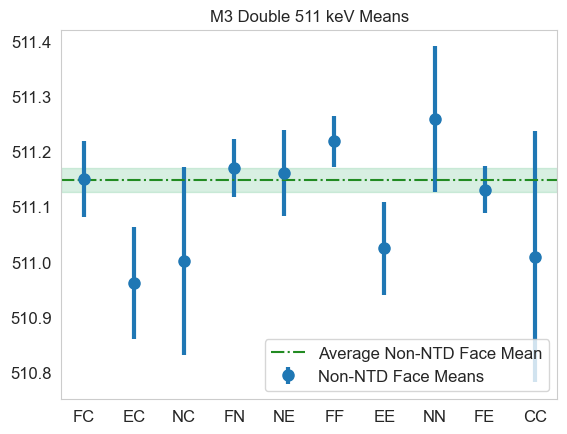

In [89]:
topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

mu_intersections = [[FCintersection_mu.geoms[0].x,FCintersection_mu.geoms[1].x],  
                      [CEintersection_mu.geoms[0].x,CEintersection_mu.geoms[1].x], 
                     [NCintersection_mu.geoms[0].x,NCintersection_mu.geoms[1].x],  
                     [FNintersection_mu.geoms[0].x,FNintersection_mu.geoms[1].x],  
                    [NEintersection_mu.geoms[0].x,NEintersection_mu.geoms[1].x], 
                    [FFintersection_mu.geoms[0].x,FFintersection_mu.geoms[1].x],  
                    [EEintersection_mu.geoms[0].x,EEintersection_mu.geoms[1].x],
                   [NNintersection_mu.geoms[0].x,NNintersection_mu.geoms[1].x],  [FEintersection_mu.geoms[0].x,FEintersection_mu.geoms[1].x], 
                   [CCintersection_mu.geoms[0].x,CCintersection_mu.geoms[1].x] ]

means = [FCmu_fit, CEmu_fit, NCmu_fit, FNmu_fit, NEmu_fit, FFmu_fit, EEmu_fit, NNmu_fit, FEmu_fit, CCmu_fit]

asymmetric_errormu = Errors(mu_intersections, means)

fig, ax = plt.subplots()

ax.errorbar(topologiesNonNTD, means, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# ax.errorbar(topologiesNonNTD, meansc2, yerr=asymmetric_errormuc2,fmt='o',ms=8, elinewidth=3, color='darkblue', label='Non-NTD Face Means (Crystal 2)')

ax.axhspan(intersection_mu.geoms[0].x, intersection_mu.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(mu_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

# ax.axhspan(intersection_muc2.geoms[0].x, intersection_muc2.geoms[1].x, color='mediumseagreen', alpha=0.2)
# ax.axhline(mu_fitc2, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean (Crystal 1)')

ax.legend(loc='lower right',fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Double 511 keV Means')

Text(0.5, 1.0, 'M3 Double 511 keV Means (Crystal 1)')

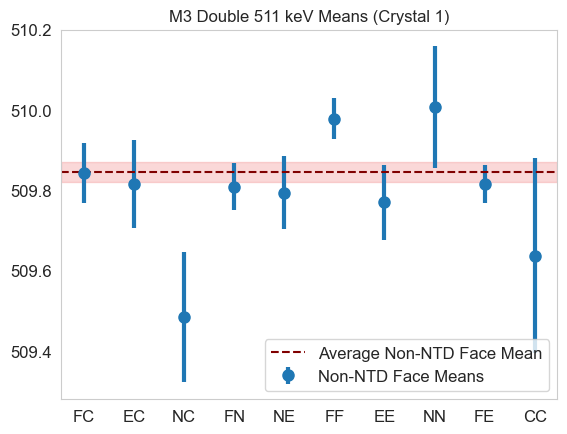

In [53]:
topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

mu_intersectionsc1 = [[FCintersection_muc1.geoms[0].x,FCintersection_muc1.geoms[1].x],  
                      [CEintersection_muc1.geoms[0].x,CEintersection_muc1.geoms[1].x], 
                     [NCintersection_muc1.geoms[0].x,NCintersection_muc1.geoms[1].x],  
                     [FNintersection_muc1.geoms[0].x,FNintersection_muc1.geoms[1].x],  
                    [NEintersection_muc1.geoms[0].x,NEintersection_muc1.geoms[1].x], 
                    [FFintersection_muc1.geoms[0].x,FFintersection_muc1.geoms[1].x],  
                    [EEintersection_muc1.geoms[0].x,EEintersection_muc1.geoms[1].x],
                   [NNintersection_muc1.geoms[0].x,NNintersection_muc1.geoms[1].x],  [FEintersection_muc1.geoms[0].x,FEintersection_muc1.geoms[1].x], 
                   [CCintersection_muc1.geoms[0].x,CCintersection_muc1.geoms[1].x] ]

mu_intersectionsc2 = [[FCintersection_muc2.geoms[0].x,FCintersection_muc2.geoms[1].x],  
                      [CEintersection_muc2.geoms[0].x,CEintersection_muc2.geoms[1].x], 
                     [NCintersection_muc2.geoms[0].x,NCintersection_muc2.geoms[1].x],  
                     [FNintersection_muc2.geoms[0].x,FNintersection_muc2.geoms[1].x],  
                    [NEintersection_muc2.geoms[0].x,NEintersection_muc2.geoms[1].x], 
                    [FFintersection_muc2.geoms[0].x,FFintersection_muc2.geoms[1].x],  
                    [EEintersection_muc2.geoms[0].x,EEintersection_muc2.geoms[1].x],
                   [NNintersection_muc2.geoms[0].x,NNintersection_muc2.geoms[1].x],  [FEintersection_muc2.geoms[0].x,FEintersection_muc2.geoms[1].x], 
                   [CCintersection_muc2.geoms[0].x,CCintersection_muc2.geoms[1].x] ]

meansc1 = [FCmu_fitc1, CEmu_fitc1, NCmu_fitc1, FNmu_fitc1, NEmu_fitc1, FFmu_fitc1, EEmu_fitc1, NNmu_fitc1, FEmu_fitc1, CCmu_fitc1]
meansc2 = [FCmu_fitc2, CEmu_fitc2, NCmu_fitc2, FNmu_fitc2, NEmu_fitc2, FFmu_fitc2, EEmu_fitc2, NNmu_fitc2, FEmu_fitc2, CCmu_fitc2]

asymmetric_errormuc1 = Errors(mu_intersectionsc1, meansc1)
asymmetric_errormuc2 = Errors(mu_intersectionsc2, meansc2)

fig, ax = plt.subplots()

ax.errorbar(topologiesNonNTD, meansc1, yerr=asymmetric_errormuc1, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# ax.errorbar(topologiesNonNTD, meansc2, yerr=asymmetric_errormuc2,fmt='o',ms=8, elinewidth=3, color='darkblue', label='Non-NTD Face Means (Crystal 2)')

ax.axhspan(intersection_muc1.geoms[0].x, intersection_muc1.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(mu_fitc1, color='maroon', linestyle='--', label='Average Non-NTD Face Mean')

# ax.axhspan(intersection_muc2.geoms[0].x, intersection_muc2.geoms[1].x, color='mediumseagreen', alpha=0.2)
# ax.axhline(mu_fitc2, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean (Crystal 1)')

ax.legend(loc='lower right',fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Double 511 keV Means (Crystal 1)')

Text(0.5, 1.0, 'M3 Double 511 keV Means (Crystal 2)')

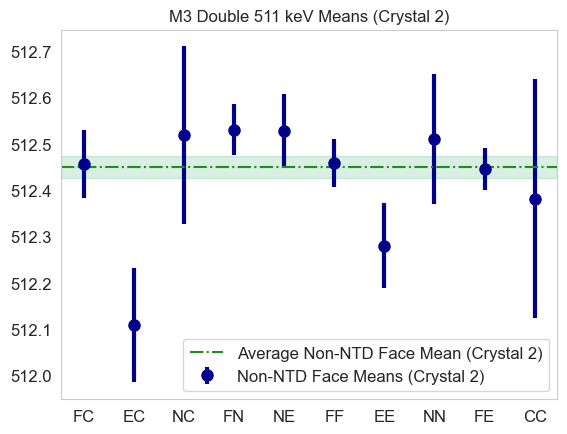

In [55]:
fig, ax = plt.subplots()

ax.errorbar(topologiesNonNTD, meansc2, yerr=asymmetric_errormuc2,fmt='o',ms=8, elinewidth=3, color='darkblue', label='Non-NTD Face Means (Crystal 2)')

ax.axhspan(intersection_muc2.geoms[0].x, intersection_muc2.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(mu_fitc2, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean (Crystal 2)')

ax.legend(loc='lower right',fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Double 511 keV Means (Crystal 2)')

Text(0.5, 1.0, 'M3 Double 511 keV Standard Dev.')

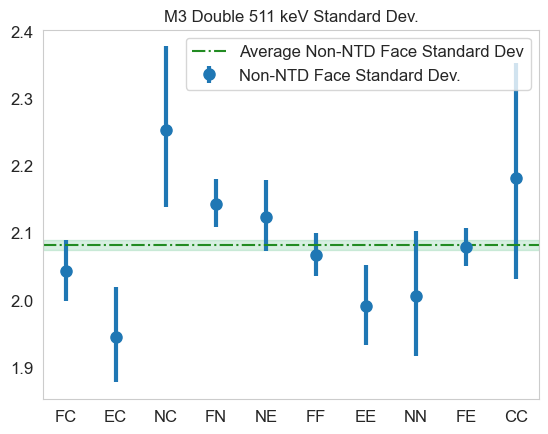

In [91]:
topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

sigma_intersections = [[FCintersection_sigma.geoms[0].x,FCintersection_sigma.geoms[1].x],  [CEintersection_sigma.geoms[0].x,CEintersection_sigma.geoms[1].x], 
                     [NCintersection_sigma.geoms[0].x,NCintersection_sigma.geoms[1].x],  
                     [FNintersection_sigma.geoms[0].x,FNintersection_sigma.geoms[1].x],  
                    [NEintersection_sigma.geoms[0].x,NEintersection_sigma.geoms[1].x], 
                    [FFintersection_sigma.geoms[0].x,FFintersection_sigma.geoms[1].x],  
                    [EEintersection_sigma.geoms[0].x,EEintersection_sigma.geoms[1].x],
                   [NNintersection_sigma.geoms[0].x,NNintersection_sigma.geoms[1].x],  [FEintersection_sigma.geoms[0].x,FEintersection_sigma.geoms[1].x], 
                    [CCintersection_sigma.geoms[0].x,CCintersection_sigma.geoms[1].x]]

sds = [FCsigma_fit, CEsigma_fit, NCsigma_fit, FNsigma_fit, NEsigma_fit, FFsigma_fit, EEsigma_fit, NNsigma_fit, FEsigma_fit, CCsigma_fit]

asymmetric_errorsigma = Errors(sigma_intersections, sds)

fig, ax = plt.subplots()
ax.errorbar(topologiesNonNTD, sds, yerr=asymmetric_errorsigma, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Standard Dev.')

ax.axhspan(intersection_sigma.geoms[0].x, intersection_sigma.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(sigma_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev')

ax.legend(fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
ax.grid(False)
ax.set_title('M3 Double 511 keV Standard Dev.')

Text(0.5, 1.0, 'M3 Double 511 keV Standard Dev.')

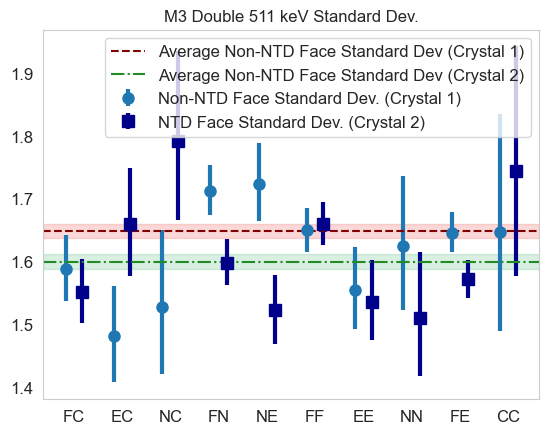

In [60]:
topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

sigma_intersectionsc1 = [[FCintersection_sigmac1.geoms[0].x,FCintersection_sigmac1.geoms[1].x],  [CEintersection_sigmac1.geoms[0].x,CEintersection_sigmac1.geoms[1].x], 
                     [NCintersection_sigmac1.geoms[0].x,NCintersection_sigmac1.geoms[1].x],  
                     [FNintersection_sigmac1.geoms[0].x,FNintersection_sigmac1.geoms[1].x],  
                    [NEintersection_sigmac1.geoms[0].x,NEintersection_sigmac1.geoms[1].x], 
                    [FFintersection_sigmac1.geoms[0].x,FFintersection_sigmac1.geoms[1].x],  
                    [EEintersection_sigmac1.geoms[0].x,EEintersection_sigmac1.geoms[1].x],
                   [NNintersection_sigmac1.geoms[0].x,NNintersection_sigmac1.geoms[1].x],  [FEintersection_sigmac1.geoms[0].x,FEintersection_sigmac1.geoms[1].x], 
                    [CCintersection_sigmac1.geoms[0].x,CCintersection_sigmac1.geoms[1].x]]

sigma_intersectionsc2 = [[FCintersection_sigmac2.geoms[0].x,FCintersection_sigmac2.geoms[1].x],  [CEintersection_sigmac2.geoms[0].x,CEintersection_sigmac2.geoms[1].x], 
                     [NCintersection_sigmac2.geoms[0].x,NCintersection_sigmac2.geoms[1].x],  
                     [FNintersection_sigmac2.geoms[0].x,FNintersection_sigmac2.geoms[1].x],  
                    [NEintersection_sigmac2.geoms[0].x,NEintersection_sigmac2.geoms[1].x], 
                    [FFintersection_sigmac2.geoms[0].x,FFintersection_sigmac2.geoms[1].x],  
                    [EEintersection_sigmac2.geoms[0].x,EEintersection_sigmac2.geoms[1].x],
                   [NNintersection_sigmac2.geoms[0].x,NNintersection_sigmac2.geoms[1].x],  [FEintersection_sigmac2.geoms[0].x,FEintersection_sigmac2.geoms[1].x], 
                    [CCintersection_sigmac2.geoms[0].x,CCintersection_sigmac2.geoms[1].x]]

sdsc1 = [FCsigma_fitc1, CEsigma_fitc1, NCsigma_fitc1, FNsigma_fitc1, NEsigma_fitc1, FFsigma_fitc1, EEsigma_fitc1, NNsigma_fitc1, FEsigma_fitc1, CCsigma_fitc1]
sdsc2 = [FCsigma_fitc2, CEsigma_fitc2, NCsigma_fitc2, FNsigma_fitc2, NEsigma_fitc2, FFsigma_fitc2, EEsigma_fitc2, NNsigma_fitc2, FEsigma_fitc2, CCsigma_fitc2]

asymmetric_errorsigmac1 = Errors(sigma_intersectionsc1, sdsc1)
asymmetric_errorsigmac2 = Errors(sigma_intersectionsc2, sdsc2)


fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.17, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.17, 0.0) + ax.transData

ax.errorbar(topologiesNonNTD, sdsc1, yerr=asymmetric_errorsigmac1,transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Standard Dev. (Crystal 1)')
ax.errorbar(topologiesNonNTD, sdsc2, yerr=asymmetric_errorsigmac2, fmt='s',ms=8,transform=trans2, elinewidth=3, color='darkblue', label='NTD Face Standard Dev. (Crystal 2)')

ax.axhspan(intersection_sigmac1.geoms[0].x, intersection_sigmac1.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(sigma_fitc1, color='maroon', linestyle='--', label='Average Non-NTD Face Standard Dev (Crystal 1)')

ax.axhspan(intersection_sigmac2.geoms[0].x, intersection_sigmac2.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(sigma_fitc2, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev (Crystal 2)')

ax.legend(fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
ax.grid(False)
ax.set_title('M3 Double 511 keV Standard Dev.')

In [85]:
for i in range(len(sds)):
    print(topologiesNonNTD[i]+' '+ str(sds[i]) + '-' + str(asymmetric_errorsigma[0][i]) + '+' + str(asymmetric_errorsigma[1][i]))
    
print(sigma_fit)
print(sigma_fit - intersection_sigma.geoms[0].x)
print(sigma_fit - intersection_sigma.geoms[1].x)

print(sigma_fit)
print(sigma_fit - intersection_sigma.geoms[0].x)
print(sigma_fit - intersection_sigma.geoms[1].x)

FC 2.0427500616683796-0.044710980709605774+0.046984920840579036
EC 1.9455881577421574-0.06843276651226593+0.07305963090670131
NC 2.252722659714887-0.11365141906841503+0.12469550804855078
FN 2.143471624363944-0.035284137798593296+0.036215025201487006
NE 2.124230646332102-0.05180600220775+0.05483516516326592
FF 2.0673626065238957-0.03169444210370065+0.03229991917789832
EE 1.9907851371307892-0.05728358975093428+0.06087910246976236
NN 2.006231036643985-0.08932827046050162+0.09628487456416224
FE 2.0782796292387946-0.02799818031196022+0.02944866850558636
CC 2.181964522445254-0.15042404471358095+0.1709358402943364
2.0817756224269557
-0.007675600808722205
0.007325176084375329
2.0817756224269557
-0.007675600808722205
0.007325176084375329


In [87]:
for i in range(len(means)):
    print(topologiesNonNTD[i]+' '+str(means[i]) + '-' + str(asymmetric_errormu[0][i]) + '+' + str(asymmetric_errormu[1][i]))
    
print(mu_fit)
print(mu_fit - intersection_mu.geoms[0].x)
print(mu_fit - intersection_mu.geoms[1].x)

print(mu_fit)
print(mu_fit - intersection_mu.geoms[0].x)
print(mu_fit - intersection_mu.geoms[1].x)

FC 511.1501504233149-0.0684163209625126+0.06841632096279682
EC 510.9621576722409-0.101994115520597+0.10199411552076754
NC 511.0017685270273-0.1698057505631141+0.16980575056322778
FN 511.1700721130219-0.05244363992227363+0.05244363992227363
NE 511.16122549788884-0.07842426588268836+0.07842426588297258
FF 511.218725997211-0.04587323869077409+0.04587323869083093
EE 511.02512676329104-0.08422823464655949+0.08422823464655949
NN 511.25867885550394-0.13172517795334215+0.13172517795334215
FE 511.13081766706875-0.04260653054745944+0.04260653054723207
CC 511.0093964749809-0.22751091671295853+0.22751091671312906
511.1483611862428
-0.02179916832494655
0.02184319861498807
511.1483611862428
-0.02179916832494655
0.02184319861498807
